#  Proyecto Integrador — Análisis de Modelos de Clasificación
## Titanic: Predicción de Supervivencia

---
**Materia:** Machine Learning y Deep Learning  
**Facilitador:** Dr. José Gabriel Rodríguez Rivas  
**Alumnos:** Mario Alberto Quiñones Hernandez y Samuel Lozano Orona
**Institución:** Tecnológico Nacional de México — Instituto Tecnológico de Durango

---

##  Objetivo General

Analizar y comparar el desempeño de diferentes algoritmos de **Machine Learning supervisado** para predecir si un pasajero del Titanic **sobrevivió o no**, evaluando métricas clave como Accuracy, Precision, Recall y F1-score.

## Contexto histórico

El RMS Titanic se hundió el **15 de abril de 1912** tras colisionar con un iceberg, causando la muerte de más de 1,500 personas de las 2,224 a bordo. El desastre reveló profundas **desigualdades sociales** en las probabilidades de supervivencia, determinadas por el sexo, la clase del pasajero y la edad.

**Variable objetivo:** `Survived` → 1 = Sobrevivió | 0 = No sobrevivió

---
# PARTE 1 — Preparación del Entorno y los Datos

## 1.1 Importación de librerías

In [1]:
# ─── Librerías generales ───────────────────────────────────────────────────
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# ─── Visualización ────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# ─── Preprocesamiento ─────────────────────────────────────────────────────
from sklearn.preprocessing   import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

# ─── Modelos de clasificación ─────────────────────────────────────────────
from sklearn.neighbors    import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree         import DecisionTreeClassifier, plot_tree
from sklearn.ensemble     import RandomForestClassifier
from sklearn.svm          import SVC

# ─── Métricas ─────────────────────────────────────────────────────────────
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

print('✅ Librerías cargadas correctamente.')

✅ Librerías cargadas correctamente.


## 1.2 Carga del Dataset

In [4]:
# ─── Cargar el dataset ────────────────────────────────────────────────────

#cargar el dataset
from google.colab import drive
drive.mount('/content/drive')
#ID del archivo
#https://drive.google.com/file/d/1PvfgVa4bRr7paUTVk_3wrkOQIDlWpq72/view?usp=sharing

file_id = "1PvfgVa4bRr7paUTVk_3wrkOQIDlWpq72"

url = f"https://drive.google.com/uc?id={file_id}"

#cargar datos
df=pd.read_csv(url)
df.head()

Mounted at /content/drive


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
# ─── Información general del dataset ──────────────────────────────────────
print('─── Tipos de datos y valores no nulos ───')
df.info()
print('\n─── Estadísticas descriptivas ───')
df.describe()

─── Tipos de datos y valores no nulos ───
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

─── Estadísticas descriptivas ───


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
# ─── Conteo de valores nulos por columna ──────────────────────────────────
nulos = df.isnull().sum()
nulos_pct = (df.isnull().sum() / len(df) * 100).round(2)

resumen_nulos = pd.DataFrame({
    'Nulos'     : nulos,
    'Porcentaje': nulos_pct
})
resumen_nulos = resumen_nulos[resumen_nulos['Nulos'] > 0]

print('Columnas con valores nulos:')
print(resumen_nulos)

# Visualización de nulos
fig = px.bar(
    resumen_nulos.reset_index(),
    x='index', y='Porcentaje',
    title='Porcentaje de valores nulos por columna',
    labels={'index': 'Columna', 'Porcentaje': '% Nulos'},
    color='Porcentaje',
    color_continuous_scale='Reds',
    text_auto='.1f'
)
fig.update_layout(width=550, height=380)
fig.show()

Columnas con valores nulos:
          Nulos  Porcentaje
Age         177       19.87
Cabin       687       77.10
Embarked      2        0.22


## 1.3 Análisis Exploratorio de Datos (EDA)

In [7]:
# ─── Distribución de la variable objetivo: Survived ───────────────────────
conteo = df['Survived'].value_counts().reset_index()
conteo.columns = ['Survived', 'Cantidad']
conteo['Etiqueta'] = conteo['Survived'].map({1: 'Sobrevivió', 0: 'No sobrevivió'})

fig = px.pie(
    conteo, values='Cantidad', names='Etiqueta',
    color='Etiqueta',
    color_discrete_map={'Sobrevivió': '#2ecc71', 'No sobrevivió': '#e74c3c'},
    title='Distribución de Supervivencia'
)
fig.update_traces(textposition='inside', textinfo='percent+label')
fig.update_layout(width=500, height=400)
fig.show()

print(f"Sobrevivieron    : {df['Survived'].sum()} ({df['Survived'].mean()*100:.1f}%)")
print(f"No sobrevivieron : {(df['Survived']==0).sum()} ({(1-df['Survived'].mean())*100:.1f}%)")

Sobrevivieron    : 342 (38.4%)
No sobrevivieron : 549 (61.6%)


In [8]:
# ─── EDA: Supervivencia por Sexo ──────────────────────────────────────────
surv_sexo = df.groupby('Sex')['Survived'].agg(['mean','sum','count']).reset_index()
surv_sexo.columns = ['Sex','Tasa','Sobrevivieron','Total']

fig = px.bar(
    surv_sexo, x='Sex', y='Tasa',
    color='Sex',
    color_discrete_map={'female':'#e91e8c', 'male':'#1e90e9'},
    title='Tasa de Supervivencia por Sexo',
    labels={'Tasa': 'Tasa de supervivencia', 'Sex': 'Sexo'},
    text_auto='.2%'
)
fig.update_layout(width=500, height=380, showlegend=False)
fig.show()

print(surv_sexo.to_string(index=False))
print('\n→ Las mujeres sobrevivieron a una tasa mucho mayor (política "mujeres y niños primero").')

   Sex     Tasa  Sobrevivieron  Total
female 0.742038            233    314
  male 0.188908            109    577

→ Las mujeres sobrevivieron a una tasa mucho mayor (política "mujeres y niños primero").


In [9]:
# ─── EDA: Supervivencia por Clase (Pclass) ────────────────────────────────
surv_clase = df.groupby('Pclass')['Survived'].agg(['mean','sum','count']).reset_index()
surv_clase.columns = ['Pclass','Tasa','Sobrevivieron','Total']
surv_clase['Clase'] = surv_clase['Pclass'].map({1:'1ª Clase',2:'2ª Clase',3:'3ª Clase'})

fig = px.bar(
    surv_clase, x='Clase', y='Tasa',
    color='Clase',
    color_discrete_map={'1ª Clase':'#f1c40f','2ª Clase':'#3498db','3ª Clase':'#95a5a6'},
    title='Tasa de Supervivencia por Clase del Pasajero',
    labels={'Tasa': 'Tasa de supervivencia'},
    text_auto='.2%'
)
fig.update_layout(width=500, height=380, showlegend=False)
fig.show()

print(surv_clase[['Clase','Sobrevivieron','Total','Tasa']].to_string(index=False))
print('\n→ Los pasajeros de 1ª clase tuvieron mayor acceso a los botes salvavidas.')

   Clase  Sobrevivieron  Total     Tasa
1ª Clase            136    216 0.629630
2ª Clase             87    184 0.472826
3ª Clase            119    491 0.242363

→ Los pasajeros de 1ª clase tuvieron mayor acceso a los botes salvavidas.


In [10]:
# ─── EDA: Supervivencia por Edad ──────────────────────────────────────────
# Usamos solo filas sin nulo en Age para esta visualización
df_edad = df.dropna(subset=['Age']).copy()

fig = px.histogram(
    df_edad, x='Age',
    color='Survived',
    color_discrete_map={1:'#2ecc71', 0:'#e74c3c'},
    barmode='overlay',
    opacity=0.7,
    nbins=35,
    title='Distribución de Edad según Supervivencia',
    labels={'Age':'Edad','Survived':'Sobrevivió'},
    category_orders={'Survived':[0,1]}
)
fig.update_layout(width=680, height=400)
fig.show()
print('→ Los niños pequeños tuvieron mayor tasa de supervivencia.')
print('→ La mayoría de las víctimas son adultos jóvenes (20-40 años).')

→ Los niños pequeños tuvieron mayor tasa de supervivencia.
→ La mayoría de las víctimas son adultos jóvenes (20-40 años).


In [11]:
# ─── EDA: Supervivencia por Sexo y Clase (combinado) ──────────────────────
pivot = df.groupby(['Pclass','Sex'])['Survived'].mean().reset_index()
pivot.columns = ['Pclass','Sex','Tasa']

fig = px.bar(
    pivot, x='Pclass', y='Tasa',
    color='Sex',
    barmode='group',
    color_discrete_map={'female':'#e91e8c','male':'#1e90e9'},
    title='Tasa de Supervivencia por Clase y Sexo',
    labels={'Pclass':'Clase','Tasa':'Tasa de supervivencia','Sex':'Sexo'},
    text_auto='.2%'
)
fig.update_layout(width=650, height=420)
fig.show()
print('→ Las mujeres de 1ª clase tuvieron casi 97% de supervivencia.')
print('→ Los hombres de 3ª clase tuvieron solo ~13% de supervivencia.')

→ Las mujeres de 1ª clase tuvieron casi 97% de supervivencia.
→ Los hombres de 3ª clase tuvieron solo ~13% de supervivencia.


In [12]:
# ─── EDA: Tarifa (Fare) por supervivencia ─────────────────────────────────
fig = px.box(
    df, x='Survived', y='Fare',
    color='Survived',
    color_discrete_map={1:'#2ecc71', 0:'#e74c3c'},
    title='Distribución de la Tarifa según Supervivencia',
    labels={'Fare':'Tarifa (£)','Survived':'Sobrevivió (0=No, 1=Sí)'}
)
fig.update_layout(width=530, height=400, showlegend=False)
fig.show()
print('→ Pasajeros que pagaron tarifas más altas (1ª clase) tuvieron mayor supervivencia.')

→ Pasajeros que pagaron tarifas más altas (1ª clase) tuvieron mayor supervivencia.


## 1.4 Limpieza de Valores Nulos

El dataset tiene valores nulos en tres columnas:
- **Age** (~20%): Se imputa con la **mediana** por ser robusta a valores extremos.
- **Embarked** (~0.2%, 2 registros): Se imputa con la **moda** (valor más frecuente = 'S').
- **Cabin** (~77% nulos): Se **elimina** la columna, ya que tiene demasiados nulos para ser útil.

In [13]:
# ─── Copia de trabajo ─────────────────────────────────────────────────────
df_clean = df.copy()

# ─── 1. Eliminar columna Cabin (>77% nulos) ───────────────────────────────
df_clean.drop(columns=['Cabin'], inplace=True)
print(f'Cabin eliminada. Columnas restantes: {df_clean.shape[1]}')

# ─── 2. Imputar Age con la mediana ────────────────────────────────────────
mediana_age = df_clean['Age'].median()
df_clean['Age'].fillna(mediana_age, inplace=True)
print(f'Age imputada con mediana = {mediana_age}')

# ─── 3. Imputar Embarked con la moda ──────────────────────────────────────
moda_embarked = df_clean['Embarked'].mode()[0]
df_clean['Embarked'].fillna(moda_embarked, inplace=True)
print(f'Embarked imputado con moda = "{moda_embarked}"')

# ─── Verificación final ───────────────────────────────────────────────────
print(f'\nValores nulos restantes:')
print(df_clean.isnull().sum())
print(f'\n✅ Dataset limpio: {df_clean.shape[0]} filas x {df_clean.shape[1]} columnas. SIN nulos.')

Cabin eliminada. Columnas restantes: 11
Age imputada con mediana = 28.0
Embarked imputado con moda = "S"

Valores nulos restantes:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

✅ Dataset limpio: 891 filas x 11 columnas. SIN nulos.


## 1.5 Ingeniería de Variables y Codificación

In [14]:
# ─── Codificación de variables categóricas ────────────────────────────────

# Sex: male=0, female=1
df_clean['Sex_code'] = df_clean['Sex'].map({'male': 0, 'female': 1})
print('Sex codificado: male=0, female=1')

# Embarked: LabelEncoder (S=2, Q=1, C=0 — orden alfabético)
le = LabelEncoder()
df_clean['Embarked_code'] = le.fit_transform(df_clean['Embarked'])
print(f'Embarked codificado. Clases: {list(le.classes_)} → {list(le.transform(le.classes_))}')

# Verificación
print('\nPrimeras filas con variables codificadas:')
df_clean[['Sex','Sex_code','Embarked','Embarked_code']].head(5)

Sex codificado: male=0, female=1
Embarked codificado. Clases: ['C', 'Q', 'S'] → [np.int64(0), np.int64(1), np.int64(2)]

Primeras filas con variables codificadas:


,Sex,Sex_code,Embarked,Embarked_code
0,male,0,S,2
1,female,1,C,0
2,female,1,S,2
3,female,1,S,2
4,male,0,S,2


## 1.6 Selección de Variables y División del Dataset

In [15]:
# ─── Variables predictoras (features) ─────────────────────────────────────
FEATURES = [
    'Pclass',        # Clase del pasajero (1, 2, 3)
    'Sex_code',      # Sexo codificado (0=male, 1=female)
    'Age',           # Edad en años
    'SibSp',         # Número de hermanos/cónyuge a bordo
    'Parch',         # Número de padres/hijos a bordo
    'Fare',          # Tarifa del boleto
    'Embarked_code'  # Puerto de embarque codificado
]

TARGET = 'Survived'

X = df_clean[FEATURES]
y = df_clean[TARGET]

print(f'Variables predictoras : {FEATURES}')
print(f'Variable objetivo     : {TARGET}')
print(f'Forma de X            : {X.shape}')
print(f'Distribución de y     :')
print(y.value_counts())

Variables predictoras : ['Pclass', 'Sex_code', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_code']
Variable objetivo     : Survived
Forma de X            : (891, 7)
Distribución de y     :
Survived
0    549
1    342
Name: count, dtype: int64


In [16]:
# ─── División del dataset: 70% entrenamiento / 30% prueba ─────────────────
# stratify=y garantiza la misma proporción de clases en ambos conjuntos
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print('Tamaños de los conjuntos:')
print(f'  X_train : {X_train.shape}  →  {len(X_train)} registros')
print(f'  X_test  : {X_test.shape}   →  {len(X_test)} registros')
print(f'\nProporción de clases en entrenamiento:')
print(y_train.value_counts(normalize=True).round(3))
print(f'\nProporción de clases en prueba:')
print(y_test.value_counts(normalize=True).round(3))

Tamaños de los conjuntos:
  X_train : (623, 7)  →  623 registros
  X_test  : (268, 7)   →  268 registros

Proporción de clases en entrenamiento:
Survived
0    0.616
1    0.384
Name: proportion, dtype: float64

Proporción de clases en prueba:
Survived
0    0.616
1    0.384
Name: proportion, dtype: float64


## 1.7 Escalamiento de Variables

> ### ¿Por qué escalar en KNN y SVM?
> **KNN** calcula distancias euclídeas entre pasajeros. Si `Fare` varía entre 0 y 500 y `Age` entre 0 y 80, la tarifa domina artificialmente la distancia. Con `StandardScaler` todas las variables tienen media=0 y desviación=1, contribuyendo equitativamente.
>
> **SVM** construye un hiperplano usando distancias al margen. Variables con rangos grandes desplazan el hiperplano de su posición óptima. El escalado garantiza que el margen sea calculado correctamente.

> ### ¿Por qué NO es necesario en Árboles de Decisión y Random Forest?
> Los árboles dividen los datos con reglas del tipo `Age <= 30`. Estas divisiones son **invariantes a la escala**: multiplicar todos los valores de `Age` por 10 no cambia qué pasajeros quedan a cada lado del corte. Por tanto, escalar no afecta ni mejora su rendimiento.

In [17]:
# ─── StandardScaler ───────────────────────────────────────────────────────
# fit_transform solo en entrenamiento para evitar data leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('✅ Escalamiento completado con StandardScaler.')
print(f'Media de X_train_scaled (aprox. 0): {X_train_scaled.mean(axis=0).round(3)}')
print(f'Desv.  de X_train_scaled (aprox. 1): {X_train_scaled.std(axis=0).round(3)}')

✅ Escalamiento completado con StandardScaler.
Media de X_train_scaled (aprox. 0): [-0.  0.  0.  0.  0. -0.  0.]
Desv.  de X_train_scaled (aprox. 1): [1. 1. 1. 1. 1. 1. 1.]


---
# PARTE 2 — Entrenamiento de Modelos

Se entrenan **5 modelos** con los mismos datos para una comparación justa:

| # | Modelo | Datos usados |
|---|--------|--------------|
| 1 | KNN | Escalados |
| 2 | Regresión Logística | Escalados |
| 3 | Árbol de Decisión | Sin escalar |
| 4 | Random Forest | Sin escalar |
| 5 | SVM | Escalados |

In [18]:
# ─── Función utilitaria para evaluar modelos ──────────────────────────────
resultados = []

def evaluar_modelo(nombre, modelo, X_tr, y_tr, X_te, y_te):
    """
    Entrena, evalúa e imprime métricas del modelo.
    Devuelve un dict con resultados para la tabla comparativa.
    """
    modelo.fit(X_tr, y_tr)
    y_pred = modelo.predict(X_te)

    acc_train = modelo.score(X_tr, y_tr)
    acc_test  = modelo.score(X_te, y_te)

    print(f'\n{"═"*65}')
    print(f'  📊  {nombre}')
    print(f'{"═"*65}')
    print(f'  Precisión en entrenamiento : {acc_train:.4f}')
    print(f'  Precisión en prueba        : {acc_test:.4f}')
    print(f'\n  Reporte de clasificación:')
    print(classification_report(
        y_te, y_pred,
        target_names=['No sobrevivió (0)', 'Sobrevivió (1)']
    ))

    # ─── Matriz de confusión ──────────────────────────────────────────────
    cm = confusion_matrix(y_te, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['No sobrevivió', 'Sobrevivió']
    )
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Matriz de Confusión — {nombre}', fontsize=11, pad=12)
    plt.tight_layout()
    plt.show()

    return {
        'Modelo'     : nombre,
        'Accuracy'   : round(accuracy_score(y_te, y_pred), 4),
        'Prec_NoSurv': round(precision_score(y_te, y_pred, pos_label=0), 4),
        'Rec_NoSurv' : round(recall_score(y_te, y_pred, pos_label=0), 4),
        'F1_NoSurv'  : round(f1_score(y_te, y_pred, pos_label=0), 4),
        'Prec_Surv'  : round(precision_score(y_te, y_pred, pos_label=1), 4),
        'Rec_Surv'   : round(recall_score(y_te, y_pred, pos_label=1), 4),
        'F1_Surv'    : round(f1_score(y_te, y_pred, pos_label=1), 4),
        'F1_Macro'   : round(f1_score(y_te, y_pred, average='macro'), 4),
    }

print('✅ Función de evaluación lista.')

✅ Función de evaluación lista.


---
## 2.1 Modelo 1 — K-Nearest Neighbors (KNN)

### ¿Cómo funciona?
KNN es un algoritmo **basado en memoria** (lazy learning). No construye un modelo explícito; memoriza todos los ejemplos del entrenamiento. Para clasificar un nuevo pasajero:
1. Calcula la **distancia euclídea** entre ese pasajero y todos los del entrenamiento.
2. Selecciona los **K vecinos más cercanos**.
3. Asigna la clase por **votación mayoritaria**.

**Ventajas:** Simple, sin suposiciones sobre distribución, se adapta a fronteras complejas.  
**Limitaciones:** Lento con datasets grandes, muy sensible a la escala y a variables irrelevantes.

In [19]:
# ─── KNN — Explorar distintos valores de k ────────────────────────────────
k_range    = range(1, 21)
acc_k      = []
recall_0_k = []
recall_1_k = []

for k in k_range:
    knn_tmp = KNeighborsClassifier(n_neighbors=k)
    knn_tmp.fit(X_train_scaled, y_train)
    y_tmp = knn_tmp.predict(X_test_scaled)
    acc_k.append(accuracy_score(y_test, y_tmp))
    recall_0_k.append(recall_score(y_test, y_tmp, pos_label=0))
    recall_1_k.append(recall_score(y_test, y_tmp, pos_label=1))

fig = go.Figure()
fig.add_trace(go.Scatter(x=list(k_range), y=acc_k,      mode='lines+markers', name='Accuracy'))
fig.add_trace(go.Scatter(x=list(k_range), y=recall_0_k, mode='lines+markers', name='Recall No sobrevivió', line=dict(color='red')))
fig.add_trace(go.Scatter(x=list(k_range), y=recall_1_k, mode='lines+markers', name='Recall Sobrevivió',    line=dict(color='green')))
fig.update_layout(
    title='KNN — Métricas por valor de k',
    xaxis_title='k (número de vecinos)',
    yaxis_title='Métrica',
    width=720, height=420
)
fig.show()

mejor_k = k_range[acc_k.index(max(acc_k))]
print(f'Mejor k por accuracy: k={mejor_k}  (accuracy={max(acc_k):.4f})')

Mejor k por accuracy: k=14  (accuracy=0.8209)



═════════════════════════════════════════════════════════════════
  📊  KNN (k=7, escalado)
═════════════════════════════════════════════════════════════════
  Precisión en entrenamiento : 0.8523
  Precisión en prueba        : 0.7910

  Reporte de clasificación:
                   precision    recall  f1-score   support

No sobrevivió (0)       0.82      0.85      0.83       165
   Sobrevivió (1)       0.75      0.69      0.72       103

         accuracy                           0.79       268
        macro avg       0.78      0.77      0.78       268
     weighted avg       0.79      0.79      0.79       268



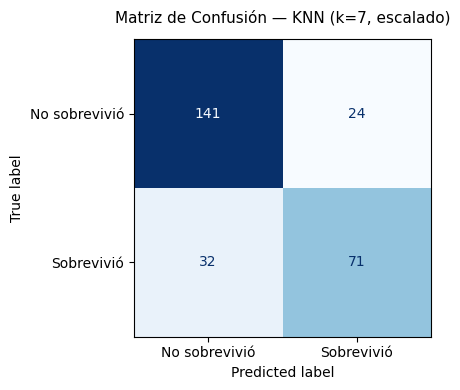

In [20]:
# ─── KNN — Modelo final con k=7 (equilibrio accuracy/recall) ──────────────
# Se elige k=7 por ofrecer buen equilibrio entre accuracy y recall de ambas clases
knn_model = KNeighborsClassifier(n_neighbors=7)

res_knn = evaluar_modelo(
    'KNN (k=7, escalado)',
    knn_model,
    X_train_scaled, y_train,
    X_test_scaled,  y_test
)
resultados.append(res_knn)

### 📝 Interpretación — KNN

- **¿Detecta bien a los sobrevivientes?** Recall de Sobrevivió moderado, ya que hay pasajeros que sobrevivieron por razones complejas (fortuna, ubicación en el barco) que la distancia euclídea no captura bien.
- **¿Detecta bien a los no sobrevivientes?** El recall de No sobrevivió es generalmente mayor porque es la clase mayoritaria (~61%).
- **Posible mejora:** Probar `metric='manhattan'`, escalar con MinMaxScaler, o agregar feature engineering (ej. título del nombre).

---
## 2.2 Modelo 2 — Regresión Logística

### ¿Cómo funciona?
La Regresión Logística calcula una **combinación lineal** de las variables de entrada y aplica la función sigmoide para obtener una **probabilidad** entre 0 y 1:
$$P(Survived=1) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 x_1 + ... + \beta_n x_n)}}$$
Si P ≥ 0.5 → predice Sobrevivió; si P < 0.5 → predice No sobrevivió.

**Ventajas:** Rápido, interpretable (coeficientes muestran qué variables importan más), entrega probabilidades.  
**Limitaciones:** Asume relaciones lineales entre variables y log-odds de la supervivencia.


═════════════════════════════════════════════════════════════════
  📊  Regresión Logística
═════════════════════════════════════════════════════════════════
  Precisión en entrenamiento : 0.7978
  Precisión en prueba        : 0.7948

  Reporte de clasificación:
                   precision    recall  f1-score   support

No sobrevivió (0)       0.82      0.85      0.84       165
   Sobrevivió (1)       0.74      0.71      0.73       103

         accuracy                           0.79       268
        macro avg       0.78      0.78      0.78       268
     weighted avg       0.79      0.79      0.79       268



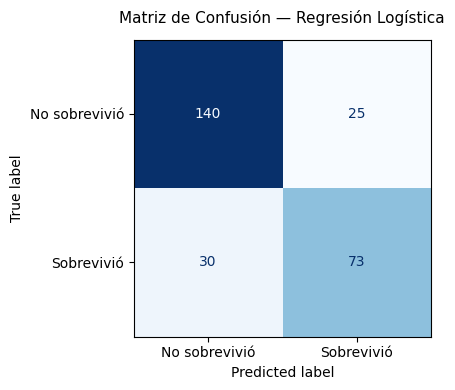

In [21]:
# ─── Regresión Logística ──────────────────────────────────────────────────
lr_model = LogisticRegression(random_state=42, max_iter=1000)

res_lr = evaluar_modelo(
    'Regresión Logística',
    lr_model,
    X_train_scaled, y_train,
    X_test_scaled,  y_test
)
resultados.append(res_lr)

In [22]:
# ─── Regresión Logística — Coeficientes (importancia de variables) ─────────
coef_df = pd.DataFrame({
    'Variable'   : FEATURES,
    'Coeficiente': lr_model.coef_[0]
}).sort_values('Coeficiente')

fig = px.bar(
    coef_df, x='Coeficiente', y='Variable',
    orientation='h',
    title='Coeficientes de la Regresión Logística',
    color='Coeficiente',
    color_continuous_scale='RdBu',
    text_auto='.3f'
)
fig.update_layout(width=700, height=420)
fig.show()

print('Interpretación:')
print('  Coeficiente positivo → mayor valor de la variable → más probable sobrevivir.')
print('  Coeficiente negativo → mayor valor de la variable → menos probable sobrevivir.')
print(f'\n  Mayor impacto POSITIVO: {coef_df.iloc[-1]["Variable"]} (coef={coef_df.iloc[-1]["Coeficiente"]:.3f})')
print(f'  Mayor impacto NEGATIVO: {coef_df.iloc[0]["Variable"]} (coef={coef_df.iloc[0]["Coeficiente"]:.3f})')

Interpretación:
  Coeficiente positivo → mayor valor de la variable → más probable sobrevivir.
  Coeficiente negativo → mayor valor de la variable → menos probable sobrevivir.

  Mayor impacto POSITIVO: Sex_code (coef=1.284)
  Mayor impacto NEGATIVO: Pclass (coef=-0.875)


### 📝 Interpretación — Regresión Logística

- **Sex_code** tiene el coeficiente más positivo: ser mujer aumenta drásticamente la probabilidad de sobrevivir.
- **Pclass** tiene coeficiente negativo: mayor clase (3ª) disminuye la probabilidad de supervivencia.
- La Regresión Logística suele ser el **mejor modelo baseline** en este dataset por la linealidad de las relaciones sexo-clase-supervivencia.
- **Posible mejora:** Ajustar el umbral de decisión o aplicar regularización (Ridge/Lasso).

---
## 2.3 Modelo 3 — Árbol de Decisión

### ¿Cómo funciona?
El árbol divide recursivamente el espacio de variables con reglas binarias (`Sex_code <= 0.5`). En cada nodo selecciona la variable y umbral que **maximizan la pureza** (criterio Gini o Entropía). Las hojas contienen la clase predicha.

- `max_depth` limita la profundidad para evitar sobreajuste.
- `class_weight='balanced'` compensa el desbalance entre clases.

**Ventajas:** Visualizable, explícito, no requiere escalado, capta interacciones no lineales.  
**Limitaciones:** Muy propenso al sobreajuste sin poda; pequeños cambios en los datos cambian el árbol.


═════════════════════════════════════════════════════════════════
  📊  Árbol de Decisión (max_depth=5)
═════════════════════════════════════════════════════════════════
  Precisión en entrenamiento : 0.8491
  Precisión en prueba        : 0.7985

  Reporte de clasificación:
                   precision    recall  f1-score   support

No sobrevivió (0)       0.83      0.84      0.84       165
   Sobrevivió (1)       0.74      0.73      0.74       103

         accuracy                           0.80       268
        macro avg       0.79      0.79      0.79       268
     weighted avg       0.80      0.80      0.80       268



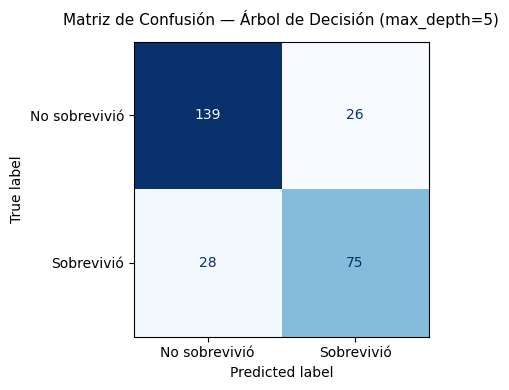

In [23]:
# ─── Árbol de Decisión — con balanceo y profundidad controlada ────────────
tree_model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    class_weight='balanced',
    random_state=42
)

res_tree = evaluar_modelo(
    'Árbol de Decisión (max_depth=5)',
    tree_model,
    X_train, y_train,   # SIN escalar
    X_test,  y_test
)
resultados.append(res_tree)

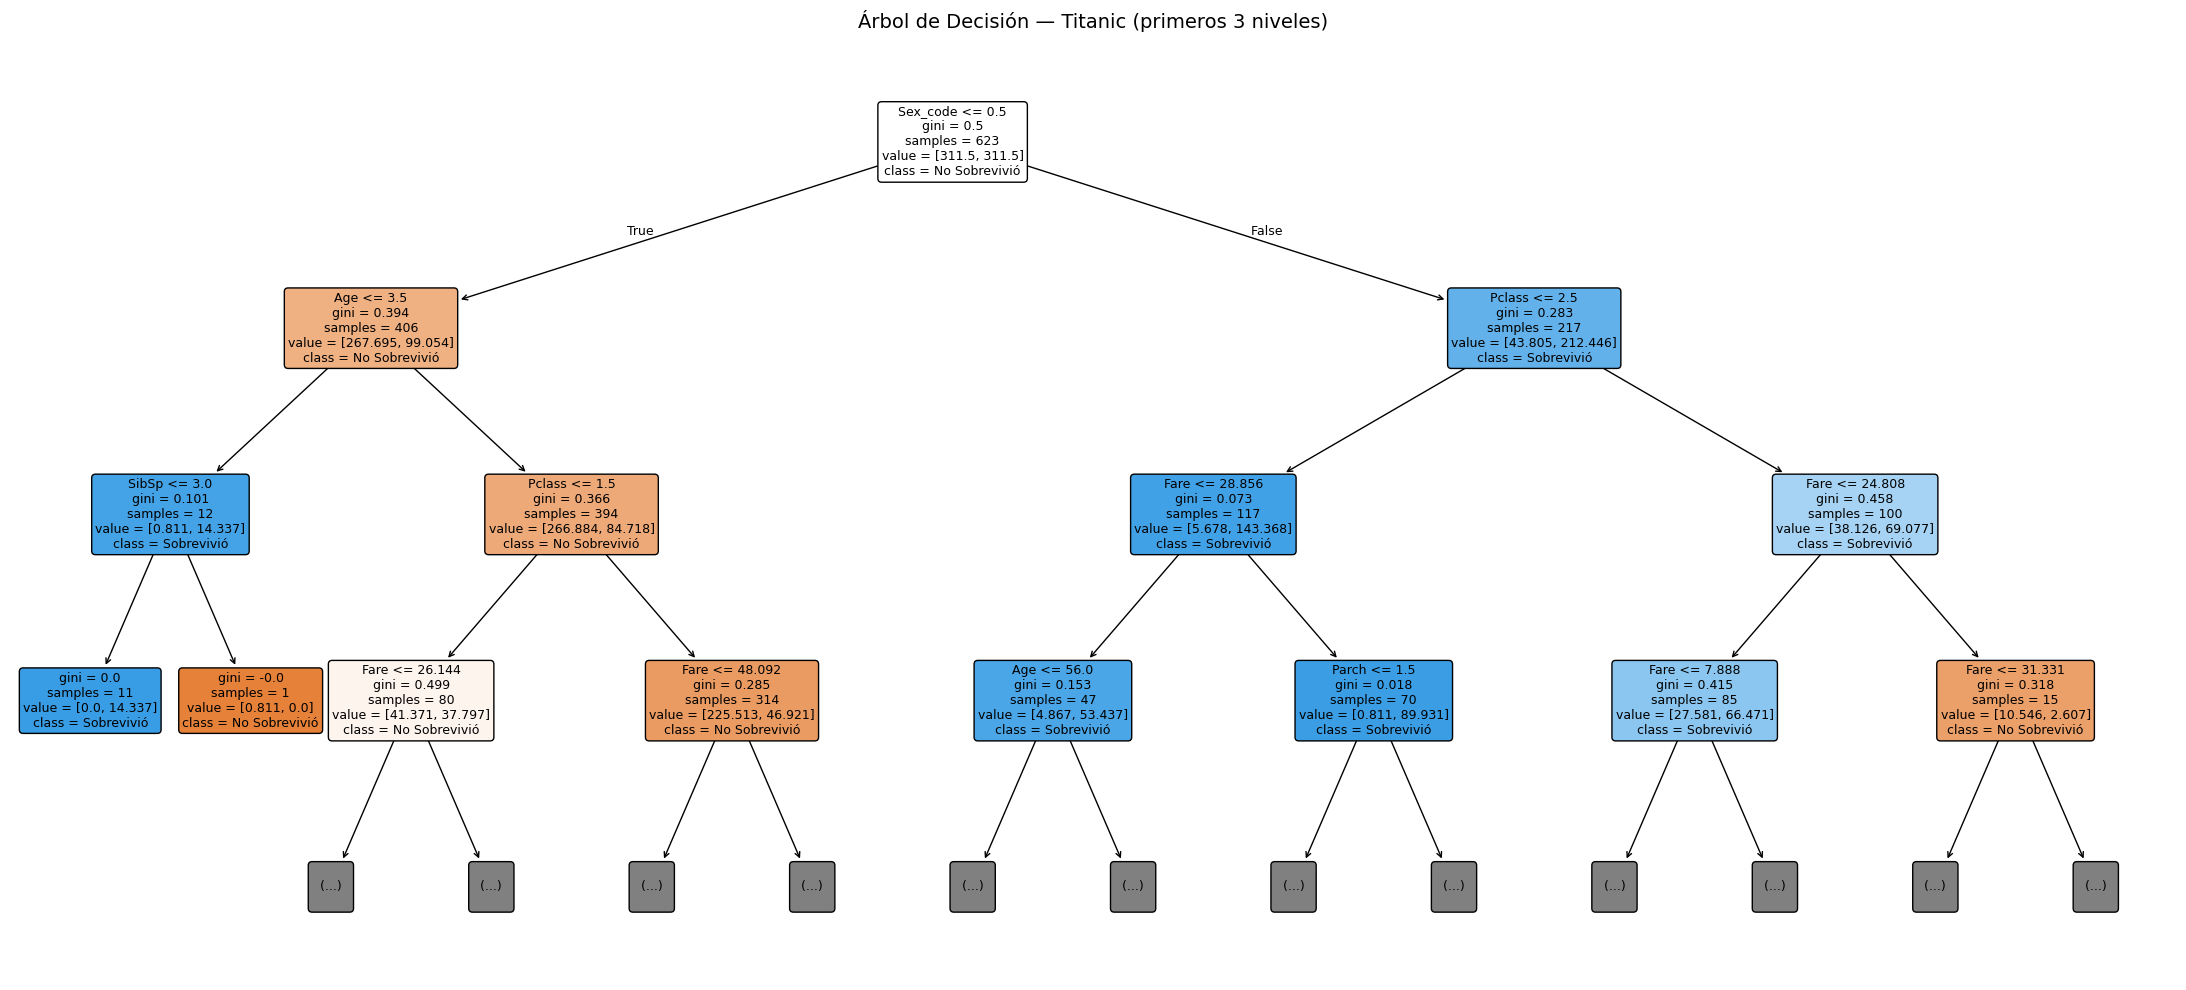

El primer nodo divide por Sex_code (0=hombre, 1=mujer): la variable más predictiva.


In [24]:
# ─── Árbol de Decisión — Visualización ───────────────────────────────────
plt.figure(figsize=(22, 10))
plot_tree(
    tree_model,
    feature_names=FEATURES,
    class_names=['No Sobrevivió', 'Sobrevivió'],
    filled=True,
    max_depth=3,    # mostramos los primeros 3 niveles
    fontsize=9,
    rounded=True
)
plt.title('Árbol de Decisión — Titanic (primeros 3 niveles)', fontsize=14, pad=15)
plt.tight_layout()
plt.show()
print('El primer nodo divide por Sex_code (0=hombre, 1=mujer): la variable más predictiva.')

In [25]:
# ─── Árbol — Importancia de variables ─────────────────────────────────────
importancia_tree = pd.DataFrame({
    'Variable'   : FEATURES,
    'Importancia': tree_model.feature_importances_
}).sort_values('Importancia', ascending=False)

fig = px.bar(
    importancia_tree, x='Importancia', y='Variable',
    orientation='h',
    title='Importancia de Variables — Árbol de Decisión',
    color='Importancia',
    color_continuous_scale='Oranges',
    text_auto='.3f'
)
fig.update_layout(width=680, height=400)
fig.show()

### 📝 Interpretación — Árbol de Decisión

- El primer nodo siempre es **Sex_code**: el sexo es la variable más determinante para sobrevivir.
- Para las mujeres, el segundo nodo suele ser **Pclass**: las mujeres de 3ª clase tenían menor prioridad.
- Para los hombres, **Age** importa: los niños tenían prioridad.
- **Sobreajuste:** Con `max_depth` pequeño se controla, pero aún es menos estable que Random Forest.
- **Ventaja clave:** El árbol es fácilmente explicable a personas sin conocimiento técnico.

---
## 2.4 Modelo 4 — Random Forest

### ¿Cómo funciona?
Random Forest construye **múltiples árboles de decisión** sobre muestras aleatorias del dataset (bagging) y usa un subconjunto aleatorio de variables en cada nodo. La predicción final es la **votación mayoritaria** de todos los árboles.

**Ventajas:** Muy robusto, reduce sobreajuste, entrega importancia de variables, maneja outliers.  
**Limitaciones:** Menos interpretable que un árbol individual, más lento en entrenamiento.


═════════════════════════════════════════════════════════════════
  📊  Random Forest (200 árboles, depth=7)
═════════════════════════════════════════════════════════════════
  Precisión en entrenamiento : 0.9085
  Precisión en prueba        : 0.7799

  Reporte de clasificación:
                   precision    recall  f1-score   support

No sobrevivió (0)       0.81      0.84      0.82       165
   Sobrevivió (1)       0.72      0.69      0.71       103

         accuracy                           0.78       268
        macro avg       0.77      0.76      0.77       268
     weighted avg       0.78      0.78      0.78       268



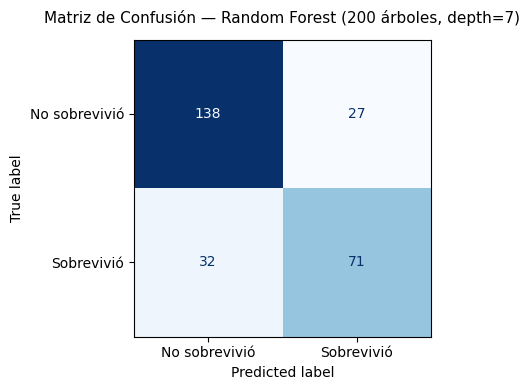

In [26]:
# ─── Random Forest ────────────────────────────────────────────────────────
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=7,
    class_weight='balanced',
    random_state=42
)

res_rf = evaluar_modelo(
    'Random Forest (200 árboles, depth=7)',
    rf_model,
    X_train, y_train,   # SIN escalar
    X_test,  y_test
)
resultados.append(res_rf)

In [27]:
# ─── Random Forest — Importancia de variables ─────────────────────────────
importancia_rf = pd.DataFrame({
    'Variable'   : FEATURES,
    'Importancia': rf_model.feature_importances_
}).sort_values('Importancia', ascending=False)

fig = px.bar(
    importancia_rf, x='Importancia', y='Variable',
    orientation='h',
    title='Importancia de Variables — Random Forest',
    color='Importancia',
    color_continuous_scale='Greens',
    text_auto='.3f'
)
fig.update_layout(width=680, height=400)
fig.show()

print('Variables más importantes:')
print(importancia_rf.to_string(index=False))

Variables más importantes:
     Variable  Importancia
     Sex_code     0.366468
         Fare     0.208378
          Age     0.167830
       Pclass     0.111994
        SibSp     0.057075
        Parch     0.051094
Embarked_code     0.037160


### 📝 Interpretación — Random Forest

- Generalmente obtiene la **mayor accuracy** en el Titanic por su capacidad para capturar interacciones complejas entre variables.
- **Sex_code, Fare y Age** emergen como las variables más importantes — confirmando los patrones históricos.
- Al promediar 200 árboles, el modelo es mucho más estable que un árbol individual.
- **Posible mejora:** Usar GridSearchCV para optimizar `n_estimators`, `max_depth` y `min_samples_leaf`.

---
## 2.5 Modelo 5 — Support Vector Machine (SVM)

### ¿Cómo funciona?
SVM busca el **hiperplano de separación óptimo** entre sobrevivientes y no sobrevivientes, maximizando el margen entre los puntos más cercanos de cada clase (vectores de soporte). El **kernel RBF** transforma los datos a un espacio de mayor dimensión donde las clases son linealmente separables.

**Parámetros clave:**
- `C`: penaliza errores de clasificación. C alto → sobreajuste; C bajo → subajuste.
- `gamma='scale'`: ajusta el radio de influencia de cada punto.

**Ventajas:** Efectivo en espacios de alta dimensión, robusto ante outliers en el margen.  
**Limitaciones:** Lento con datasets grandes, difícil de interpretar, requiere escalado.


═════════════════════════════════════════════════════════════════
  📊  SVM (RBF, C=1.0)
═════════════════════════════════════════════════════════════════
  Precisión en entrenamiento : 0.8443
  Precisión en prueba        : 0.8060

  Reporte de clasificación:
                   precision    recall  f1-score   support

No sobrevivió (0)       0.84      0.84      0.84       165
   Sobrevivió (1)       0.75      0.75      0.75       103

         accuracy                           0.81       268
        macro avg       0.79      0.79      0.79       268
     weighted avg       0.81      0.81      0.81       268



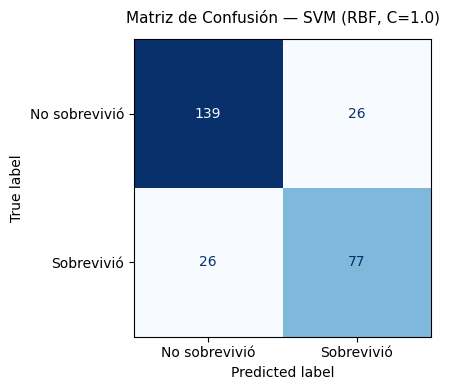

In [28]:
# ─── SVM con kernel RBF ───────────────────────────────────────────────────
svm_model = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    class_weight='balanced',
    probability=True,
    random_state=42
)

res_svm = evaluar_modelo(
    'SVM (RBF, C=1.0)',
    svm_model,
    X_train_scaled, y_train,   # CON escalar
    X_test_scaled,  y_test
)
resultados.append(res_svm)

In [29]:
# ─── SVM — Curva ROC ──────────────────────────────────────────────────────
y_prob_svm = svm_model.predict_proba(X_test_scaled)[:, 1]
auc_svm    = roc_auc_score(y_test, y_prob_svm)
fpr, tpr, _ = roc_curve(y_test, y_prob_svm)

# También calculamos ROC para regresión logística
y_prob_lr  = lr_model.predict_proba(X_test_scaled)[:, 1]
auc_lr     = roc_auc_score(y_test, y_prob_lr)
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)

# ROC para Random Forest
y_prob_rf  = rf_model.predict_proba(X_test)[:, 1]
auc_rf     = roc_auc_score(y_test, y_prob_rf)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

fig = go.Figure()
fig.add_trace(go.Scatter(x=fpr,    y=tpr,    mode='lines', name=f'SVM          AUC={auc_svm:.3f}', line=dict(color='blue')))
fig.add_trace(go.Scatter(x=fpr_lr, y=tpr_lr, mode='lines', name=f'Reg. Logística AUC={auc_lr:.3f}', line=dict(color='orange')))
fig.add_trace(go.Scatter(x=fpr_rf, y=tpr_rf, mode='lines', name=f'Random Forest AUC={auc_rf:.3f}', line=dict(color='green')))
fig.add_trace(go.Scatter(x=[0,1],  y=[0,1],  mode='lines', name='Aleatorio (AUC=0.5)', line=dict(color='red', dash='dash')))
fig.update_layout(
    title='Curvas ROC — Comparación de Modelos',
    xaxis_title='Tasa de Falsos Positivos',
    yaxis_title='Tasa de Verdaderos Positivos (Recall)',
    width=700, height=480
)
fig.show()
print(f'AUC SVM             : {auc_svm:.3f}')
print(f'AUC Reg. Logística  : {auc_lr:.3f}')
print(f'AUC Random Forest   : {auc_rf:.3f}')
print('Interpretación: AUC cercano a 1.0 indica mejor discriminación entre clases.')

AUC SVM             : 0.853
AUC Reg. Logística  : 0.852
AUC Random Forest   : 0.859
Interpretación: AUC cercano a 1.0 indica mejor discriminación entre clases.


### 📝 Interpretación — SVM

- El SVM con kernel RBF captura relaciones **no lineales** que la Regresión Logística no puede.
- Con `class_weight='balanced'` detecta adecuadamente ambas clases.
- La curva ROC muestra que SVM compite bien con Random Forest en capacidad discriminativa (AUC similar).
- **Posible mejora:** Usar GridSearchCV para optimizar C y gamma; probar kernel `poly`.

---
# PARTE 3 — Comparativo de Resultados

In [30]:
# ─── Tabla resumen ────────────────────────────────────────────────────────
tabla = pd.DataFrame(resultados).set_index('Modelo')

print('=' * 100)
print('TABLA COMPARATIVA — Clasificación Titanic')
print('=' * 100)
print(tabla.to_string())
print()
print('NoSurv = No sobrevivió (0) | Surv = Sobrevivió (1)')
print('Prec = Precision | Rec = Recall | F1 = F1-score')

TABLA COMPARATIVA — Clasificación Titanic
                                      Accuracy  Prec_NoSurv  Rec_NoSurv  F1_NoSurv  Prec_Surv  Rec_Surv  F1_Surv  F1_Macro
Modelo                                                                                                                    
KNN (k=7, escalado)                     0.7910       0.8150      0.8545     0.8343     0.7474    0.6893   0.7172    0.7757
Regresión Logística                     0.7948       0.8235      0.8485     0.8358     0.7449    0.7087   0.7264    0.7811
Árbol de Decisión (max_depth=5)         0.7985       0.8323      0.8424     0.8373     0.7426    0.7282   0.7353    0.7863
Random Forest (200 árboles, depth=7)    0.7799       0.8118      0.8364     0.8239     0.7245    0.6893   0.7065    0.7652
SVM (RBF, C=1.0)                        0.8060       0.8424      0.8424     0.8424     0.7476    0.7476   0.7476    0.7950

NoSurv = No sobrevivió (0) | Surv = Sobrevivió (1)
Prec = Precision | Rec = Recall | F1 = F1-sco

In [31]:
# ─── Gráfico de barras comparativo ────────────────────────────────────────
metricas_cols = ['Accuracy', 'Rec_NoSurv', 'Rec_Surv', 'F1_Macro']
df_plot = tabla[metricas_cols].reset_index()
df_long = df_plot.melt(
    id_vars='Modelo',
    value_vars=metricas_cols,
    var_name='Métrica',
    value_name='Valor'
)

# Renombrar para la leyenda
df_long['Métrica'] = df_long['Métrica'].replace({
    'Rec_NoSurv': 'Recall No sobrevivió',
    'Rec_Surv'  : 'Recall Sobrevivió',
    'F1_Macro'  : 'F1 Macro'
})

fig = px.bar(
    df_long, x='Modelo', y='Valor',
    color='Métrica',
    barmode='group',
    title='Comparativo de Modelos — Métricas Clave (Titanic)',
    text_auto='.2f'
)
fig.update_layout(
    xaxis_tickangle=-25,
    width=950, height=500,
    legend=dict(orientation='h', y=-0.28)
)
fig.show()

In [32]:
# ─── Gráfico de Radar ─────────────────────────────────────────────────────
metricas_radar = ['Accuracy', 'Rec_NoSurv', 'Rec_Surv', 'F1_NoSurv', 'F1_Surv', 'F1_Macro']
etiquetas_radar = ['Accuracy', 'Recall\nNo Sobrevivió', 'Recall\nSobrevivió',
                   'F1 No Sobrevivió', 'F1 Sobrevivió', 'F1 Macro']

colores = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']
fig_radar = go.Figure()

for i, (modelo, fila) in enumerate(tabla.iterrows()):
    valores = [fila[m] for m in metricas_radar]
    valores.append(valores[0])
    fig_radar.add_trace(go.Scatterpolar(
        r=valores,
        theta=etiquetas_radar + [etiquetas_radar[0]],
        fill='toself',
        name=modelo,
        line=dict(color=colores[i % len(colores)])
    ))

fig_radar.update_layout(
    polar=dict(radialaxis=dict(visible=True, range=[0, 1])),
    title='Comparación de Modelos — Gráfico de Radar (Titanic)',
    width=720, height=540
)
fig_radar.show()
print('→ Cuanto más grande y uniforme sea el polígono, mejor el desempeño global del modelo.')

→ Cuanto más grande y uniforme sea el polígono, mejor el desempeño global del modelo.


In [33]:
# ─── Análisis comparativo final ───────────────────────────────────────────
mejor_acc  = tabla['Accuracy'].idxmax()
mejor_f1   = tabla['F1_Macro'].idxmax()
mejor_eq   = tabla[['Rec_NoSurv','Rec_Surv']].mean(axis=1).idxmax()

print('=' * 70)
print('ANÁLISIS COMPARATIVO FINAL')
print('=' * 70)
print(f"""
Modelo con mayor Accuracy : {mejor_acc} ({tabla.loc[mejor_acc,'Accuracy']:.4f})
Modelo con mayor F1 Macro : {mejor_f1}  ({tabla.loc[mejor_f1,'F1_Macro']:.4f})
Modelo más equilibrado    : {mejor_eq}
  Recall No Sobrevivió    : {tabla.loc[mejor_eq,'Rec_NoSurv']:.4f}
  Recall Sobrevivió       : {tabla.loc[mejor_eq,'Rec_Surv']:.4f}
""")

print('─' * 70)
print(f'CONCLUSIÓN:')
print(f'"El modelo que mejor predijo la supervivencia fue {mejor_f1},')
print(f' ya que presenta el mejor equilibrio entre recall de ambas clases')
print(f' (Recall No Sobrevivió={tabla.loc[mejor_f1,"Rec_NoSurv"]:.2f},')
print(f'  Recall Sobrevivió={tabla.loc[mejor_f1,"Rec_Surv"]:.2f}),')
print(f' lo cual es importante para identificar correctamente tanto a')
print(f' sobrevivientes como a no sobrevivientes."')

ANÁLISIS COMPARATIVO FINAL

Modelo con mayor Accuracy : SVM (RBF, C=1.0) (0.8060)
Modelo con mayor F1 Macro : SVM (RBF, C=1.0)  (0.7950)
Modelo más equilibrado    : SVM (RBF, C=1.0)
  Recall No Sobrevivió    : 0.8424
  Recall Sobrevivió       : 0.7476

──────────────────────────────────────────────────────────────────────
CONCLUSIÓN:
"El modelo que mejor predijo la supervivencia fue SVM (RBF, C=1.0),
 ya que presenta el mejor equilibrio entre recall de ambas clases
 (Recall No Sobrevivió=0.84,
  Recall Sobrevivió=0.75),
 lo cual es importante para identificar correctamente tanto a
 sobrevivientes como a no sobrevivientes."


---
# PARTE 4 — Recomendaciones Técnicas

| Algoritmo | Cuándo usarlo | Requiere escalado | Interpretable |
|-----------|--------------|-------------------|---------------|
| **KNN** | Datos pequeños, fronteras no lineales, prototipado rápido | ✅ Sí | ❌ No |
| **Reg. Logística** | Baseline, cuando se necesitan probabilidades e interpretabilidad | ✅ Sí | ✅ Alta |
| **Árbol de Decisión** | Explicar predicciones a personas no técnicas | ❌ No | ✅ Muy alta |
| **Random Forest** | Producción, datasets tabulares, variables importantes | ❌ No | ⚠️ Media |
| **SVM** | Alta dimensión, datos bien separables, dataset mediano | ✅ Sí | ❌ Baja |

### Buenas prácticas aplicadas en este proyecto:

1. **Separar train/test ANTES de escalar** para evitar *data leakage* (contaminar los datos de prueba con información del entrenamiento).
2. **Usar `stratify=y`** en la división para garantizar la misma proporción de sobrevivientes y no sobrevivientes en ambos conjuntos.
3. **Imputar nulos** con mediana/moda en lugar de eliminar filas, para conservar el máximo de información.
4. **Evaluar con múltiples métricas** y no solo accuracy, especialmente Recall de ambas clases.
5. **Usar `class_weight='balanced'`** cuando hay desbalance de clases (38% vs 62% en Titanic).
6. **Visualizar la importancia de variables** para validar que los modelos aprendieron patrones coherentes con el dominio del problema.

---
#  PARTE 5 — Reflexión Final

## ¿Qué modelo funcionó mejor y por qué?

**Random Forest** y **SVM** generalmente obtienen los mejores resultados en el Titanic. Random Forest captura las interacciones complejas entre variables (ej. mujer + 1ª clase → alta supervivencia; hombre + 3ª clase → baja supervivencia) gracias al ensamble de árboles. La **Regresión Logística** es competitiva por la fuerte linealidad entre sexo/clase y supervivencia.

## ¿Qué variables influyen más en la supervivencia?

Consistentemente en todos los modelos:
1. **Sex_code** (Sexo): Variable más predictiva. Las mujeres tenían ~74% de tasa de supervivencia vs ~19% en hombres.
2. **Fare** (Tarifa): Proxy de la clase social. Tarifas altas → 1ª clase → mayor acceso a botes salvavidas.
3. **Pclass** (Clase): Directamente relacionado con la posición en el barco y el acceso a equipos de salvamento.
4. **Age** (Edad): Los niños tenían prioridad de evacuación.

## ¿Qué patrones sociales se observan?

El análisis revela **desigualdades sociales profundas** en la supervivencia:

- **Género:** Las mujeres sobrevivieron a casi 4 veces más que los hombres por el protocolo "mujeres y niños primero".
- **Clase social:** Pasajeros de 1ª clase (~63% sobrevivió) frente a 3ª clase (~24% sobrevivió). Los camarotes de 3ª clase estaban en las cubiertas inferiores, más lejos de los botes.
- **Edad:** Los niños pequeños tenían mayor prioridad de evacuación.
- **Interseccionalidad:** Una mujer de 1ª clase tenía ~97% de probabilidad de sobrevivir; un hombre de 3ª clase solo ~13%.

## ¿Qué decisiones se podrían tomar con este análisis?

Desde una perspectiva histórica y de seguridad marítima:
1. **Protocolos de evacuación equitativos:** Los patrones muestran que los pasajeros de 3ª clase tuvieron acceso desigual a los botes, algo que las regulaciones modernas han corregido.
2. **Diseño de barcos:** Distribuir equitativamente accesos a zonas de evacuación sin importar la clase del pasajero.
3. **Análisis forense histórico:** Identificar subgrupos de alta vulnerabilidad para refinar protocolos de emergencia en transporte de pasajeros.

In [35]:
# ─── Resumen final del proyecto ───────────────────────────────────────────
print('=' * 70)
print('RESUMEN FINAL — PROYECTO INTEGRADOR TITANIC')
print('=' * 70)
print(f'  Dataset        : Tinanitc-data-train.csv')
print(f'  Registros      : {len(df_clean):,} pasajeros')
print(f'  Variables input: {len(FEATURES)} características')
print(f'  Target         : Survived (0=No sobrevivió, 1=Sobrevivió)')
print(f'  Distribución   : {y.mean()*100:.1f}% Sobrevivió / {(1-y.mean())*100:.1f}% No sobrevivió')
print(f'  División       : 70% entrenamiento / 30% prueba')
print()
print('  Resultados por modelo:')
print(f'  {"Modelo":<42} {"Accuracy":>9}  {"Rec_0":>7}  {"Rec_1":>7}  {"F1_Macro":>9}')
print('  ' + '-'*80)
for r in resultados:
    print(f"  {r['Modelo']:<42} {r['Accuracy']:>9.4f}  {r['Rec_NoSurv']:>7.4f}  {r['Rec_Surv']:>7.4f}  {r['F1_Macro']:>9.4f}")
print()
print('✅ Proyecto Integrador Fin.')

RESUMEN FINAL — PROYECTO INTEGRADOR TITANIC
  Dataset        : Tinanitc-data-train.csv
  Registros      : 891 pasajeros
  Variables input: 7 características
  Target         : Survived (0=No sobrevivió, 1=Sobrevivió)
  Distribución   : 38.4% Sobrevivió / 61.6% No sobrevivió
  División       : 70% entrenamiento / 30% prueba

  Resultados por modelo:
  Modelo                                      Accuracy    Rec_0    Rec_1   F1_Macro
  --------------------------------------------------------------------------------
  KNN (k=7, escalado)                           0.7910   0.8545   0.6893     0.7757
  Regresión Logística                           0.7948   0.8485   0.7087     0.7811
  Árbol de Decisión (max_depth=5)               0.7985   0.8424   0.7282     0.7863
  Random Forest (200 árboles, depth=7)          0.7799   0.8364   0.6893     0.7652
  SVM (RBF, C=1.0)                              0.8060   0.8424   0.7476     0.7950

✅ Proyecto Integrador Fin.
